In [9]:
!pip install yfinance

[*********************100%***********************]  1 of 1 completed

Fetching Nifty 50 Data...
Data ready! Training on 777 days, testing on 195 days.

--- Unconstrained Tree Performance ---
Training Accuracy: 1.0000 (It basically memorised the data!)
Testing Accuracy: 0.5128 (But it fails on unseen data)


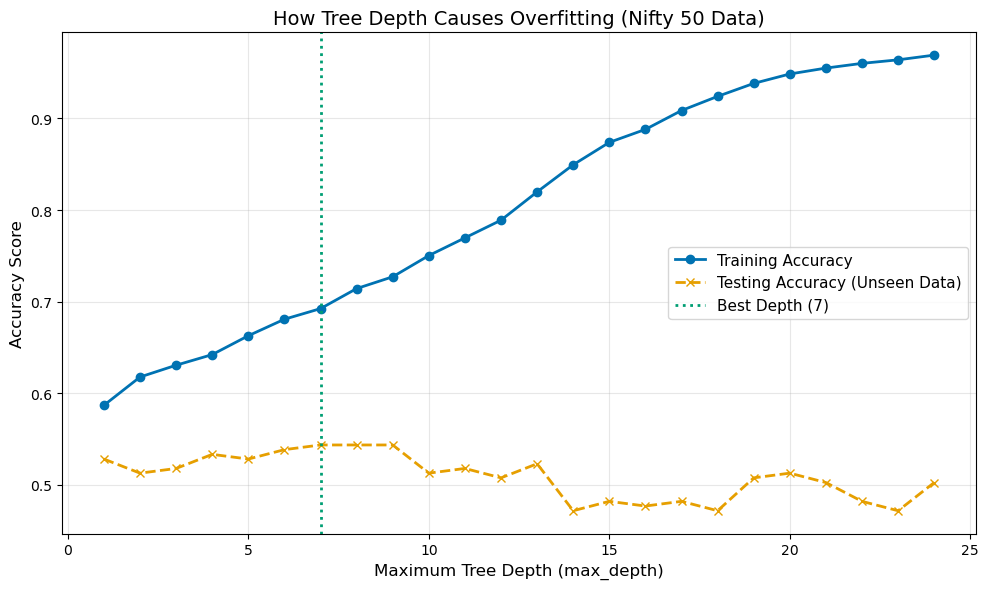


Robust Tree Testing Accuracy: 0.5077


In [10]:
# Importing the standard data science stack and yfinance to grab our market data.
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# I'm setting up a colorblind-friendly palette for the plots to make sure 
# the visualisations in my tutorial are accessible to everyone.
cb_palette = {'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73'}

# --- Fetching and Preparing the Dataset ---

# Downloading historical data for the Nifty 50 index. 
# I chose financial data because it's incredibly noisy, making it the perfect 
# sandbox to demonstrate how a model can overfit by memorising random noise.
print("Fetching Nifty 50 Data...")
nifty = yf.download('^NSEI', start='2020-01-01', end='2024-01-01')

# Creating some basic technical indicators to use as features. 
# I'm calculating the 5-day and 20-day Simple Moving Averages (SMA) to capture 
# short and medium-term trends, plus the daily percentage return.
nifty['SMA_5'] = nifty['Close'].rolling(window=5).mean()
nifty['SMA_20'] = nifty['Close'].rolling(window=20).mean()
nifty['Daily_Return'] = nifty['Close'].pct_change()

# Setting up our target variable for classification. 
# 1 = The market closed higher the next day. 0 = The market closed lower.
nifty['Target'] = np.where(nifty['Close'].shift(-1) > nifty['Close'], 1, 0)

# Cleaning up the NaN values that were created when calculating the rolling averages.
nifty.dropna(inplace=True)

# Separating the features (X) and the target we want to predict (y)
X = nifty[['SMA_5', 'SMA_20', 'Daily_Return']]
y = nifty['Target']

# Splitting the data 80/20. The random_state ensures this notebook is 
# reproducible if someone else runs it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training on {len(X_train)} days, testing on {len(X_test)} days.")

# --- Demonstrating Overfitting ---

# First, I'm going to build a completely unconstrained tree. 
# By not setting a max_depth, the tree will keep splitting until every single 
# leaf is pure (entropy hits 0). Let's see how badly it overfits.
unconstrained_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
unconstrained_tree.fit(X_train, y_train)

train_acc = accuracy_score(y_train, unconstrained_tree.predict(X_train))
test_acc = accuracy_score(y_test, unconstrained_tree.predict(X_test))

print("\n--- Unconstrained Tree Performance ---")
print(f"Training Accuracy: {train_acc:.4f} (It basically memorised the data!)")
print(f"Testing Accuracy: {test_acc:.4f} (But it fails on unseen data)")

# --- The Experiment: Finding the Sweet Spot ---

# To visualise this for the tutorial, I'll train a bunch of trees with 
# different maximum depths and track their performance.
max_depths = range(1, 25)
train_scores = []
test_scores = []

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# --- Visualising the Results ---

plt.figure(figsize=(10, 6))

# Plotting both lines. I'm making sure to use distinct markers ('o' and 'x') 
# along with the accessible colour palette so the graph is easy to read.
plt.plot(max_depths, train_scores, label='Training Accuracy', 
         color=cb_palette['blue'], marker='o', linestyle='-', linewidth=2)
plt.plot(max_depths, test_scores, label='Testing Accuracy (Unseen Data)', 
         color=cb_palette['orange'], marker='x', linestyle='--', linewidth=2)

# Finding and highlighting the depth that gave us the best test score
optimal_depth = max_depths[np.argmax(test_scores)]
plt.axvline(x=optimal_depth, color=cb_palette['green'], linestyle=':', 
            label=f'Best Depth ({optimal_depth})', linewidth=2)

plt.title('How Tree Depth Causes Overfitting (Nifty 50 Data)', fontsize=14)
plt.xlabel('Maximum Tree Depth (max_depth)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Saving the plot to drop into the written tutorial
plt.savefig('overfitting_plot.png', dpi=300)
plt.show()

# --- Fixing the Problem ---

# Finally, I'll build a more robust model using what we learned.
# I'm capping the depth and adding min_samples_leaf to force the algorithm 
# to only make splits if it has enough data points to justify it.
robust_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, criterion='entropy', random_state=42)
robust_tree.fit(X_train, y_train)

print(f"\nRobust Tree Testing Accuracy: {accuracy_score(y_test, robust_tree.predict(X_test)):.4f}")